# 01 — Khám phá dữ liệu

**Mục tiêu:** hiểu quy mô, độ thiếu, phân bố giá và phạm vi địa lý trước khi chọn mô hình.

Giá được quy về **tỷ VND**. Để tránh lộ dữ liệu cá nhân khi lưu notebook, các bảng chỉ hiển thị đặc trưng đã làm sạch, không hiển thị mô tả hoặc địa chỉ chi tiết.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "src" / "pipeline.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục dự án có src/pipeline.py")
sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from src.pipeline import (
    clean_data,
    find_column,
    load_raw_data,
    parse_price,
)

raw = load_raw_data()
cleaned, cleaning_report = clean_data(raw)
print(f"Tin đọc được: {len(raw):,}")
print(f"Tin còn lại sau làm sạch: {len(cleaned):,}")
print(f"Số trường trong CSV: {len(raw.columns)}")

schema = pd.DataFrame({
    "Vai trò": ["Giá", "Diện tích", "Phòng ngủ", "Số tầng", "Mặt tiền", "Địa chỉ"],
    "Cột CSV": [
        find_column(raw, role)
        for role in ["price", "area", "bedrooms", "floors", "width", "location"]
    ],
})
display(schema)
display(cleaning_report)


Tin đọc được: 51,304
Tin còn lại sau làm sạch: 51,132
Số trường trong CSV: 28


,Vai trò,Cột CSV
0,Giá,price
1,Diện tích,area
2,Phòng ngủ,bedrooms
3,Số tầng,floors
4,Mặt tiền,width
5,Địa chỉ,location


,metric,value
0,raw_rows,51304
1,duplicate_rows_removed,0
2,missing_or_invalid_price_removed,172
3,impossible_numeric_values_set_missing,2778
4,price_outlier_flags_iqr_log,0
5,final_rows,51132


## Chất lượng và độ phủ dữ liệu

Bảng dưới đây chỉ chứa các cột cần cho phân tích; dữ liệu gốc không được in ra notebook.

In [2]:
safe_columns = [
    "price_bil", "area_m2", "bedrooms", "floors", "frontage",
    "district", "property_type",
]
display(cleaned[safe_columns].head(10))

missing = cleaned[safe_columns].isna().mean().sort_values(ascending=False)
display(missing.rename("Tỷ lệ thiếu").to_frame())

print("Số Quận/Huyện chuẩn hóa:", cleaned["district"].nunique())
print("Số tin chưa chuẩn hóa được Quận/Huyện:",
      int(cleaned["district"].eq("__missing__").sum()))
print("Các loại bất động sản phổ biến:")
display(cleaned["property_type"].value_counts().head(10).to_frame("Số tin"))


,price_bil,area_m2,bedrooms,floors,frontage,district,property_type
0,7.50,95.0,3.0,3.0,5.0,TP_Thu_Duc,nha rieng
1,4.50,66.0,2.0,2.0,4.0,TP_Thu_Duc,nha rieng
2,7.50,92.0,3.0,3.0,5.0,Q9,nha rieng
3,4.75,45.0,3.0,2.0,4.0,TP_Thu_Duc,nha rieng
4,4.80,82.0,2.0,1.0,8.5,TP_Thu_Duc,nha rieng
5,4.75,50.0,NaN,3.0,4.0,TP_Thu_Duc,nha rieng
6,3.75,50.0,2.0,2.0,4.2,TP_Thu_Duc,nha rieng
7,4.50,110.0,2.0,1.0,5.0,TP_Thu_Duc,nha rieng
8,27.50,442.0,19.0,4.0,11.0,Q12,nha rieng
9,6.50,161.0,4.0,2.0,7.0,TP_Thu_Duc,nha rieng


,Tỷ lệ thiếu
floors,0.780118
bedrooms,0.668251
frontage,0.322440
area_m2,0.038489
price_bil,0.000000
district,0.000000
property_type,0.000000


Số Quận/Huyện chuẩn hóa: 29
Số tin chưa chuẩn hóa được Quận/Huyện: 13536
Các loại bất động sản phổ biến:


,Số tin
property_type,
dat,29424
can ho chung cu,10973
nha rieng,8179
"kho, nha xuong",1780
nha tro,537
khach san,196
van phong,43


## Phân phối giá và quan hệ với diện tích

Giá có đuôi phải dài; biểu đồ giới hạn ở phân vị 99 để phần lớn tin dễ quan sát hơn. Không xóa các tin đắt chỉ vì chúng hiếm.

,Giá (tỷ VND)
count,51132.000000
mean,32.648438
std,84.994946
min,0.100000
50%,7.000000
90%,69.000000
95%,165.000000
99%,455.000000
max,1000.000000


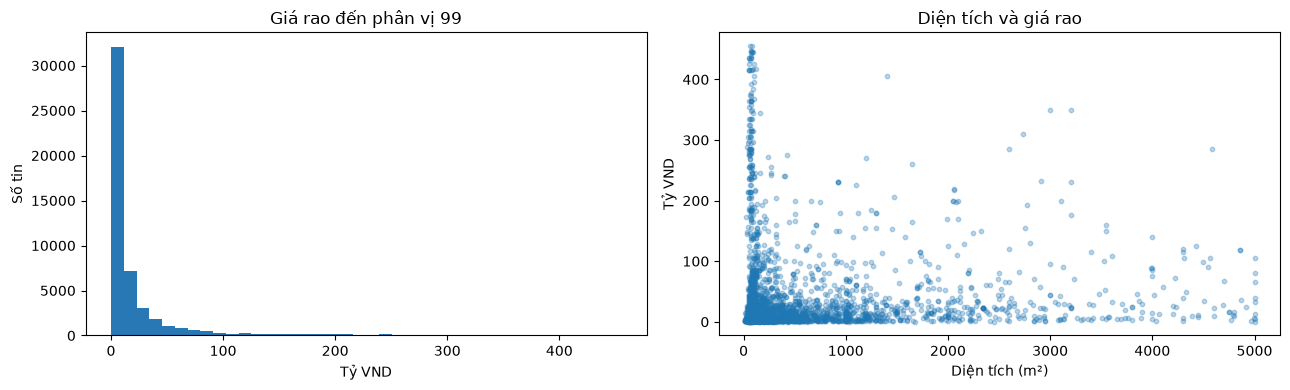

Kết luận: cần xem riêng sai số theo phân khúc; MAE/RMSE gốc chịu ảnh hưởng mạnh từ tin giá rất cao.


In [3]:
prices = cleaned["price_bil"].dropna()
display(prices.describe(percentiles=[.5, .9, .95, .99]).to_frame("Giá (tỷ VND)"))

upper_price = prices.quantile(.99)
price_view = cleaned.loc[cleaned["price_bil"] <= upper_price]
scatter = price_view.dropna(subset=["area_m2"]).sample(
    n=min(5000, price_view["area_m2"].notna().sum()),
    random_state=42,
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(price_view["price_bil"], bins=40, color="#2878B5")
axes[0].set(title="Giá rao đến phân vị 99", xlabel="Tỷ VND", ylabel="Số tin")
axes[1].scatter(scatter["area_m2"], scatter["price_bil"], s=10, alpha=.3)
axes[1].set(title="Diện tích và giá rao", xlabel="Diện tích (m²)", ylabel="Tỷ VND")
figure.tight_layout()
plt.show()

print("Kết luận: cần xem riêng sai số theo phân khúc; MAE/RMSE gốc chịu ảnh hưởng mạnh từ tin giá rất cao.")
